In [19]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Gaussian Log Likelihood

The Gaussian Log Likelihood implemented in GAMBIT follows the standard Gaussian distribution but can be calculated in two different versions. Once with an additional theory error (profiled gaussian log likelihood) and once where the theory error is interpreted as a direct input (marginalised gaussian log likelihood). In this case the Gaussian takes the form of a prior $\mathcal{L}_{G, marg.} = \mathcal{L}(x|\mu , \epsilon, \sigma_{\epsilon})$, whereas in the profiled case $\mathcal{L}_{G, prof.} = \mathcal{L}(x|\mu)$ simply maximises the normal Gaussian containing the theory error $\sigma_{\epsilon}$


The corresponding expressions are

$$
\mathrm{log}[\mathcal{L}_{G, prof.}(x|\mu)] = -\mathrm{log}(2 \pi \sigma \sigma_{\epsilon}) - \frac{1}{2} \frac{(x - \mu)^2}{\sigma^2 + \sigma_{\epsilon}^2}
$$

$$
\mathrm{log}[\mathcal{L}_{G, marg.}(x|\mu, \sigma_{\epsilon})] = -\mathrm{log}(\sqrt{2 \pi (\sigma^2 + \sigma_{\epsilon}^2)}) -\frac{1}{2} \frac{(x - \mu)^2}{\sigma^2 \sigma_{\epsilon}^2}
$$

In [4]:
def gaussian_loglikelihood(theory, obs, theoryerr, obserr, profile_systematics) -> float:
    """profiled Gaussian Log Likelihood"""
    if theoryerr == 0: profile_systematics = False
    errsq = theoryerr*theoryerr + obserr*obserr
    chi2 = -0.5 * np.pow((theory-obs),2) / errsq
    norm = np.log(2 * np.pi * obserr * theoryerr) if profile_systematics else 0.5 * np.log(2*np.pi*errsq)
    return chi2 - norm

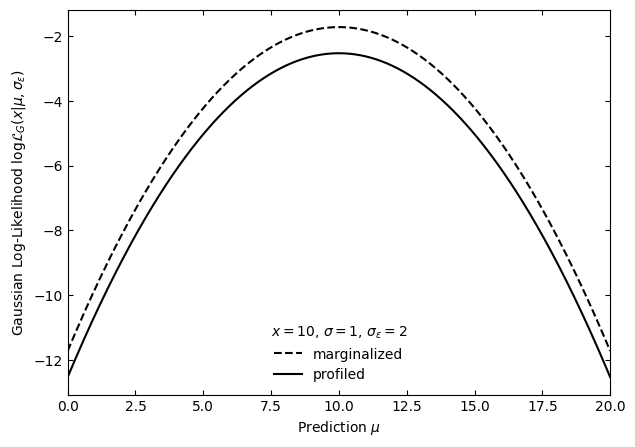

In [18]:
x = 10
sigma = 1
epsilon = 2
mu = np.linspace(0, 20, 1000)

lnL_prof = gaussian_loglikelihood(mu, x, epsilon, sigma, profile_systematics=True)
lnL_marg = gaussian_loglikelihood(mu, x, epsilon, sigma, profile_systematics=False)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
ax.set_xlim(0,20)
ax.tick_params(direction='in', which='both', top=True, right=True)
ax.plot(mu, lnL_marg, color='black', linestyle='--', label='marginalized')
ax.plot(mu, lnL_prof, color='black', label='profiled')
ax.legend(frameon=False, title="$x=10$, $\\sigma=1$, $\\sigma_{\\epsilon}=2$", loc='lower center')
ax.set_ylabel("Gaussian Log-Likelihood $\\mathrm{log}\\mathcal{L}_G(x|\\mu, \\sigma_{\\epsilon})$")
ax.set_xlabel("Prediction $\\mu$")

plt.show()

## Upper limit Gaussian Log Likelihood

The Gaussian constituted with a limit assumes flatness blow some observed limit. In this sense it can be seen as a half of the normal Gaussian Likelihood. The implementations for the profiled and the marginalised cases are

$$
\mathrm{log}[\mathcal{L}_{G \bar{\uparrow}, prof.}(x|\mu)] = 
\begin{cases}
    -\mathrm{log}(2 \pi \sigma \sigma_{\epsilon}) \quad \quad \quad \quad \quad \; \mathrm{if} \; \mu \leq x \\
    -\mathrm{log}(2 \pi \sigma \sigma_{\epsilon}) -\frac{1}{2} \frac{(x - \mu)^2}{\sigma ^2 \sigma_{\epsilon}^2} \quad \mathrm{if} \; \mu \geq x \\
\end{cases}
$$

$$
\mathrm{log}[\mathcal{L}_{G \bar{\uparrow}, marg.}(x|\mu, \sigma_{\epsilon})] = 
\mathrm{log}\left(\frac{1}{\sqrt{8 \pi}} \left[\frac{1}{\sqrt{\sigma^2 + \sigma_{\epsilon}^2}} e^{-\frac{1}{2} \frac{(x - \mu)^2}{\sigma^2 + \sigma_{\epsilon}^2}} \cdot \mathrm{erfc}\left(\frac{\sigma}{\sigma_{\epsilon}} \frac{x - \mu}{\sqrt{2(\sigma^2 + \sigma_{\epsilon}^2)}} \right) + \frac{1}{\sigma} \mathrm{erfc}\left(\frac{\mu - x}{\sqrt{2} \sigma_{\epsilon}}  \right) \right] \right)
$$

Here erfc is the complmentary error function $\mathrm{erfc}(x) = \mathrm{erf}(1-x)$. In the limit this then reads

$$
\lim_{\mu\to -\infty} \mathcal{L}_{G, \bar{\uparrow}, marg}(x|\mu, \sigma{\epsilon}) = \frac{1}{\sqrt{2 \pi} \sigma}
$$


In [33]:
def gaussian_upper_limit_loglike(theory, obs, theoryerr, obserr, profile_systematics: bool = False) -> float:
    """Calculate the log-likelihood for a Gaussian upper limit."""
    errsq = theoryerr**2 + obserr**2
    theoryerr *= theory
    if profile_systematics:
        prefactor = -0.5 * np.log(2*np.pi*errsq)
        loglike = prefactor - 0.5*np.power((theory - obs), 2)/errsq if theory > obs else prefactor
        return loglike
    else:
        prefactor = -0.5 * np.log(8*np.pi)
        diff = obs - theory
        like = np.exp(-0.5*diff**2/errsq)/np.sqrt(errsq)
        like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
        like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr
        loglike = prefactor + 1.17549e-38 if like==0 else prefactor + np.log(like)
        return loglike

/tmp/ipykernel_2293/2638194344.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
/tmp/ipykernel_2293/2638194344.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr


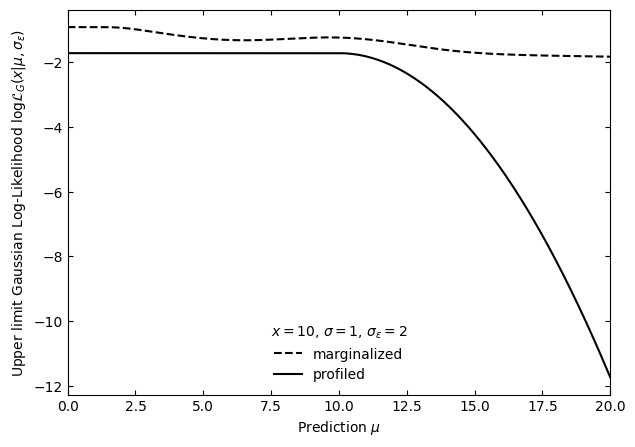

In [34]:
lnL_prof_upper = [gaussian_upper_limit_loglike(mu[i], x, epsilon, sigma, profile_systematics=True) for i in range(len(mu))]
lnL_marg_upper = [gaussian_upper_limit_loglike(mu[i], x, epsilon, sigma, profile_systematics=False) for i in range(len(mu))]

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
ax.set_xlim(0,20)
ax.tick_params(direction='in', which='both', top=True, right=True)
ax.plot(mu, lnL_marg_upper, color='black', linestyle='--', label='marginalized')
ax.plot(mu, lnL_prof_upper, color='black', label='profiled')
ax.legend(frameon=False, title="$x=10$, $\\sigma=1$, $\\sigma_{\\epsilon}=2$", loc='lower center')
ax.set_ylabel("Upper limit Gaussian Log-Likelihood $\\mathrm{log}\\mathcal{L}_G(x|\\mu, \\sigma_{\\epsilon})$")
ax.set_xlabel("Prediction $\\mu$")

plt.show()

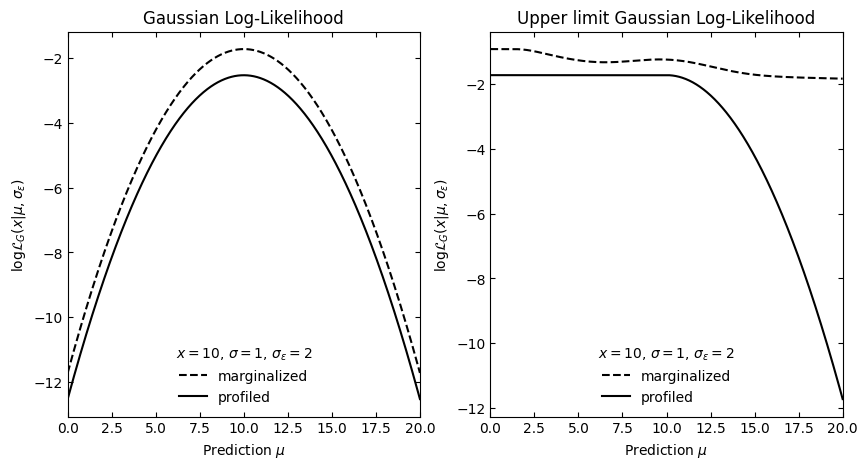

In [35]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_xlim(0,20)
ax1.tick_params(direction='in', which='both', top=True, right=True)
ax1.plot(mu, lnL_marg, color='black', linestyle='--', label='marginalized')
ax1.plot(mu, lnL_prof, color='black', label='profiled')
ax1.legend(frameon=False, title="$x=10$, $\\sigma=1$, $\\sigma_{\\epsilon}=2$", loc='lower center')
ax1.set_ylabel("$\\mathrm{log}\\mathcal{L}_G(x|\\mu, \\sigma_{\\epsilon})$")
ax1.set_xlabel("Prediction $\\mu$")
ax1.set_title("Gaussian Log-Likelihood")

ax2.set_xlim(0,20)
ax2.tick_params(direction='in', which='both', top=True, right=True)
ax2.plot(mu, lnL_marg_upper, color='black', linestyle='--', label='marginalized')
ax2.plot(mu, lnL_prof_upper, color='black', label='profiled')
ax2.legend(frameon=False, title="$x=10$, $\\sigma=1$, $\\sigma_{\\epsilon}=2$", loc='lower center')
ax2.set_ylabel("$\\mathrm{log}\\mathcal{L}_G(x|\\mu, \\sigma_{\\epsilon})$")
ax2.set_xlabel("Prediction $\\mu$")
ax2.set_title("Upper limit Gaussian Log-Likelihood")

fig.savefig("plots/likelihoods.png", dpi=1000)


plt.show()